In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

# Data
X, y = make_classification(n_samples=5000, n_features=20, n_classes=4, n_informative = 4, random_state=42)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

# Network Architecure, Training Functions and Scikit Wrapper

In [2]:
from torch import nn
from typing import Literal

class MLPClassifier(nn.Module):
    def __init__(self, n_hidden:int, hidden_dim:int, input_dim:int, output_dim:int, activation:Literal['ReLU', 'Tanh'] = 'ReLU'):
        super(MLPClassifier, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_hidden)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

        if activation == 'ReLU':
            self.activation = nn.ReLU()
        elif activation == 'Tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError(f"Unknown activation function: {activation}")

    def forward(self, input):
        x = self.activation(self.input_layer(input))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        x = self.output_layer(x)

        return x.squeeze(1) if x.shape[-1] == 1 else x

In [3]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.nn.utils import clip_grad_norm_

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_train_loaders(dataset:TensorDataset, train_idx, val_idx, batch_size:int=256, shuffle:bool=True):
    train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size)

    return train_loader, val_loader


def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        running_loss += loss.item()
        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=max_norm)
        optimizer.step()
    avg_loss = running_loss / len(loader)

    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

/home/franio/Desktop/Deep_Learning_Labs/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
import numpy as np
from torch.nn.utils import clip_grad_norm_
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import accuracy_score

class MyWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, model, classes:list | np.ndarray, lr:float=1e-3, epochs:int=50, batch_size:int=None, device:torch.device=None, is_fitted:bool = False):
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        self.model = model.to(self.device)
        self.classes = classes
        self.classes_ = classes

        self.batch_size = batch_size
        self.epochs = epochs
        self.lr = lr
        self.is_fitted  = is_fitted


    def fit(self, X: np.ndarray, y: np.ndarray, sample_weight=None) -> float:
        def _train_one_epoch(model, loader, optimizer, criterion, max_norm:float=1.0):
            model.train()
            running_loss = 0.0
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                running_loss += loss.item()
                loss.backward()
                clip_grad_norm_(model.parameters(), max_norm=max_norm)
                optimizer.step()
            avg_loss = running_loss / len(loader)

            return avg_loss

        self.model.to(self.device)
        optimzer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        if len(self.classes) == 2:
            criterion = nn.BCEWithLogitsLoss()
            y_tensor = torch.Tensor(y).to(self.device)

        else:
            criterion = nn.CrossEntropyLoss()
            y_tensor = torch.Tensor(y).long().to(self.device)

        X_tensor = torch.Tensor(X).to(self.device)

        if sample_weight is not None:
            sampler = WeightedRandomSampler(sample_weight, len(X_tensor), replacement=True)
        else:
            sampler = None

        train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=self.batch_size, sampler=sampler)

        running_loss = 0.0
        for epoch in range(self.epochs):
            running_loss += _train_one_epoch(self.model, train_loader, optimzer, criterion)

        print(f'Avrage Loss {running_loss/self.epochs}')

        self.is_fitted = True
        return self


    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X_tensor = torch.Tensor(X).to(self.device)

        self.model.eval()
        output = self.model(X_tensor)

        if len(self.classes) == 2:
            proba = torch.sigmoid(output).detach().cpu().numpy()
            proba = proba.reshape(-1, 1)
            proba = np.hstack([1 - proba, proba])
        else:
            proba = torch.softmax(output, dim=1).detach().cpu().numpy()


        return proba

    def predict(self, X: np.ndarray) -> np.ndarray:
        proba = self.predict_proba(X)

        if len(self.classes) == 2:
            preds = self.classes[(proba[:, 1] >= 0.5).astype(int)]
        else:
            preds = self.classes[proba.argmax(axis=1)]

        return preds


    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


# Training


 ===================== Training Fold 0  ===================== 



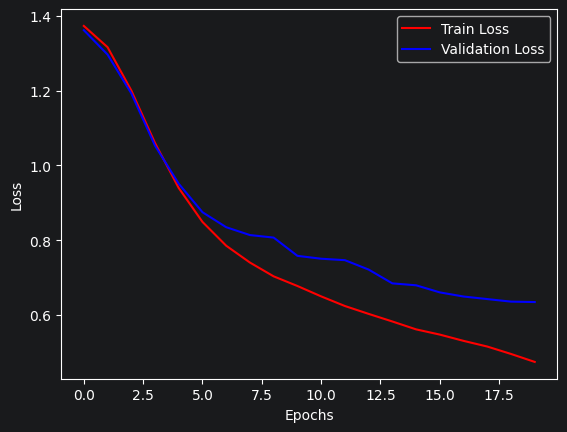


 ===================== Training Fold 1  ===================== 



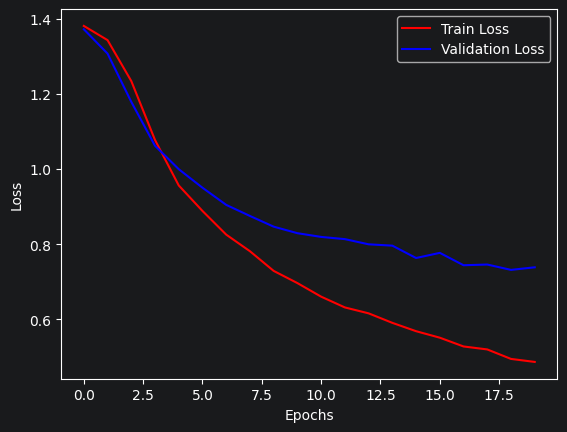


 ===================== Training Fold 2  ===================== 



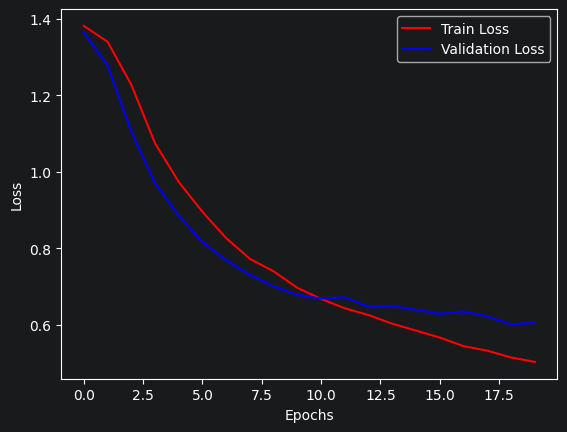


 ===================== Training Fold 3  ===================== 



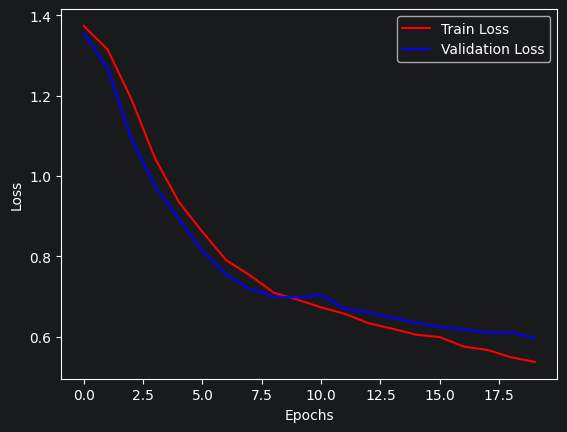


 ===================== Training Fold 4  ===================== 



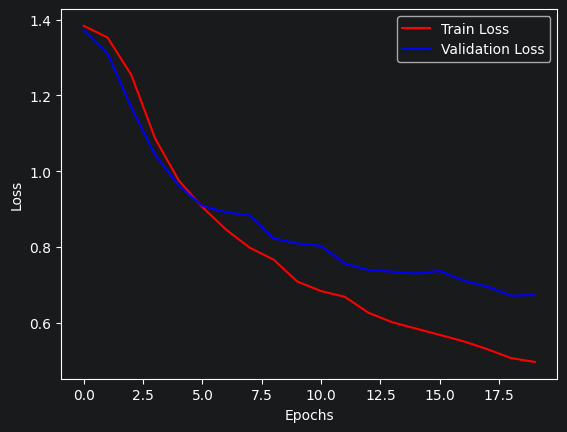

In [5]:
import numpy as np
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset
import matplotlib.pyplot as plt
import os

#paths
write_model_dir = os.path.join('Models', 'Classifier')
os.makedirs(write_model_dir, exist_ok=True)


# Hyperparameter
batch_size = 256
learning_rate = 1e-3 #https://x.com/karpathy/status/801621764144971776?lang=en
n_epochs = 20

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':len(np.unique(y_train_val))
}

# Dataset
trainval_set = TensorDataset(torch.Tensor(X_train_val).float(), torch.Tensor(y_train_val).long())

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(trainval_set)))):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')


    # Loaders
    train_loader, val_loader = get_train_loaders(
        dataset=trainval_set,
        train_idx=train_idx,
        val_idx=val_idx,
        batch_size=batch_size,
    )

    # Model, Optimizer, Criterion
    model = MLPClassifier(**model_parameter).to(DEVICE)
    Optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    history = {
        'train_loss': [],
        'val_loss': [],
    }

    for epoch in range(n_epochs):
        train_loss = _train_one_epoch(model, train_loader, Optimizer, criterion)
        val_loss = _calculate_val_loss(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if best_val_loss > val_loss:
            best_val_loss = val_loss
            model_path = os.path.join(write_model_dir, f"fold_{fold}.pth")
            torch.save(model.state_dict(), model_path)
            # print(f'Saved new best model to {model_path}, with new {best_val_loss=}')

    plt.plot(history['train_loss'], label='Train Loss', color='red')
    plt.plot(history['val_loss'], label='Validation Loss', color='blue')
    plt.grid(False)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Model Wrapping, Prediction function and Test Set Metrics

## Additional Ensemble Wrapper

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

class EnsembleWrapperClf():
    def __init__(self, models:list[MyWrapper], classes:list, is_fitted:bool = True):
        self.models = models
        self.classes = classes
        self.classes_ = classes

        self.is_fitted  = True

    def fit(self, X: np.ndarray, y: np.ndarray):
        kf = KFold(n_splits=len(self.models), shuffle=True, random_state=42)
        for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(X)))):
            self.models[fold].fit(X[train_idx], y[train_idx])

        return self



    def _mean_response(self, X:np.ndarray) -> np.ndarray:
        output = np.zeros((len(self.models), len(X), len(self.classes)))
        for idx, model in enumerate(self.models):
            output[idx] = model.predict_proba(X)

        mean = output.mean(axis=0)
        return mean

    def _majority_voting(self, X: np.ndarray) -> np.ndarray:

        vote_counts = np.zeros((len(X), len(self.classes)), dtype=np.int64)

        for model in self.models:
            preds = model.predict_proba(X).argmax(axis=1)
            vote_counts[np.arange(len(X)), preds] += 1

        return vote_counts

    def predict(self, X: np.ndarray, method:Literal['majority_voting', 'mean_response'] = 'mean_response') -> np.ndarray:
        if method == 'majority_voting':
            out = self._majority_voting(X)
        elif method == 'mean_response':
            out = self._mean_response(X)
        else:
            raise NotImplementedError

        return out.argmax(axis=1)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        out = self._mean_response(X)

        return out

    def score(self, X, y, sample_weight=None):
        check_is_fitted(self, attributes=["is_fitted"])
        y_pred = self.predict(X)

        return accuracy_score(y, y_pred, sample_weight=sample_weight)


In [32]:
MODELS_DIR = os.path.join('Models', 'Classifier')
fold_paths = [os.path.join(MODELS_DIR, f) for f in os.listdir(MODELS_DIR)]

# Model Parameters
model_parameter = {
    'n_hidden': 3,
    'hidden_dim': 64,
    'input_dim':X_train_val.shape[1],
    'output_dim':len(np.unique(y_train_val))
    }

clf_ensamble = []
for path in fold_paths:
    m = MLPClassifier(**model_parameter)
    m.load_state_dict(torch.load(path))
    clf_ensamble.append(MyWrapper(m, np.unique(y_train_val)))

clf_ensamble = EnsembleWrapperClf(clf_ensamble, np.unique(y_test))

clf_ensamble.predict_proba(X_test)

array([[5.36152059e-01, 4.88844110e-02, 4.07498682e-01, 7.46490106e-03],
       [8.10090821e-02, 5.85246243e-04, 1.59483266e-02, 9.02457356e-01],
       [3.34289673e-01, 1.54718949e-02, 6.39203519e-01, 1.10349142e-02],
       ...,
       [3.45682087e-03, 5.78756575e-03, 9.90579665e-01, 1.75902481e-04],
       [3.44003022e-01, 1.20934086e-01, 3.83055097e-01, 1.52007787e-01],
       [5.67064758e-03, 9.80364013e-01, 1.37823821e-02, 1.82936660e-04]])

## Prediction Function and Test Set Evaluation

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, classification_report, confusion_matrix
import numpy as np
import warnings

# Suppress all FutureWarnings
warnings.filterwarnings("ignore")
def report_multiclass(target: np.ndarray, y_proba: np.ndarray, y_pred: np.ndarray, classes: list):
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))
    ax = ax.flatten()

    # 1. Confusion Matrix
    cf_mtx = confusion_matrix(target, y_pred)
    sns.heatmap(cf_mtx, annot=True, fmt="g", ax=ax[0], xticklabels=classes, yticklabels=classes)
    ax[0].set_title('Confusion Matrix')
    ax[0].set_ylabel('True Label')
    ax[0].set_xlabel('Predicted Label')

    # 2. One-vs-Rest ROC Curve
    for idx, class_name in enumerate(classes):
        # target == idx creates the temporary binary 1D array for OvR evaluation
        fpr, tpr, _ = roc_curve(target == idx, y_proba[:, idx])
        roc_auc = auc(fpr, tpr)
        display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=class_name)
        display.plot(ax=ax[1])

    ax[1].plot([0, 1], [0, 1], color='black', linestyle='--')
    ax[1].set_title('Multiclass ROC Curve (One-vs-Rest)')

    plt.tight_layout()
    plt.show()

    string_classes = [str(c) for c in classes]

    # Pass string_classes to target_names
    clf_r = classification_report(target, y_pred, target_names=string_classes, zero_division=0)
    print("Classification Report:\n")
    print(clf_r)

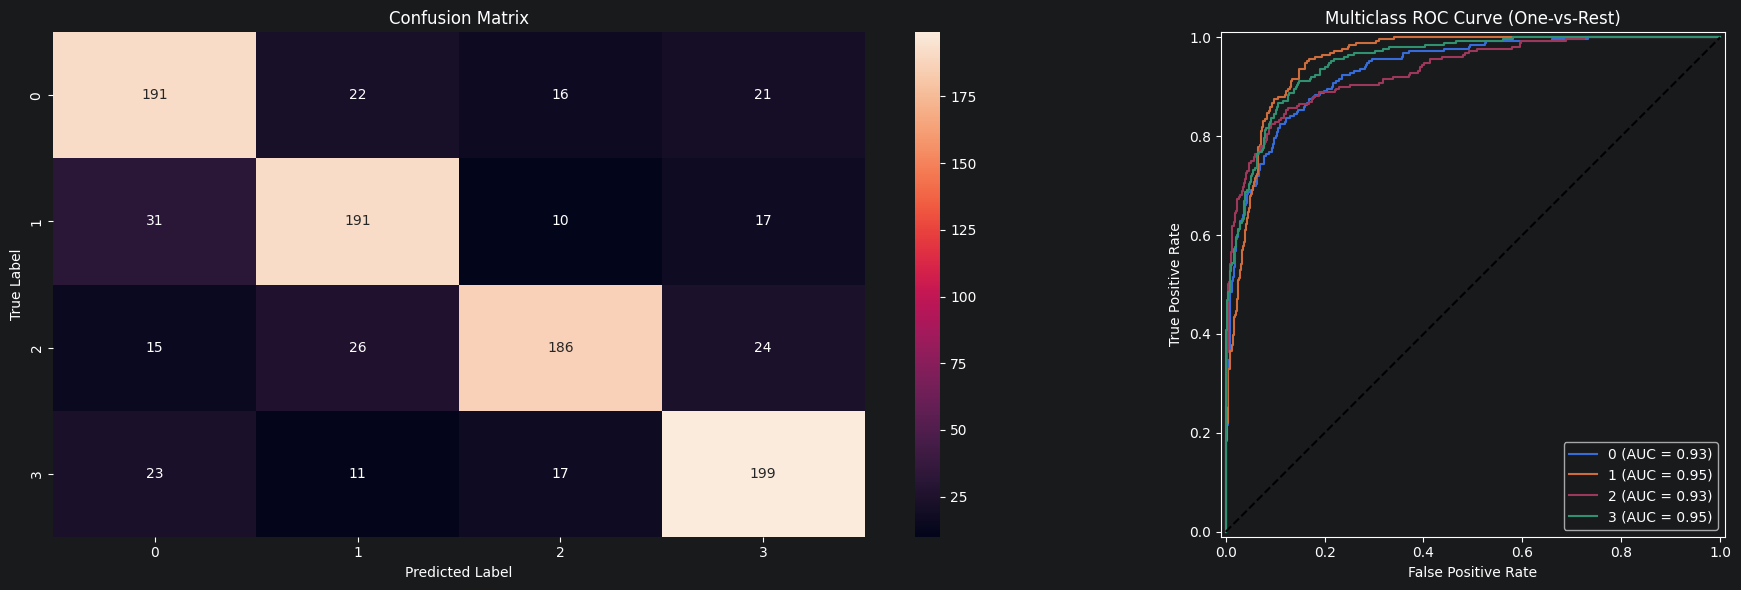

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       250
           1       0.76      0.77      0.77       249
           2       0.81      0.74      0.78       251
           3       0.76      0.80      0.78       250

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



In [29]:
classes = np.unique(y_test)
proba = clf_ensamble.predict_proba(X_test)
pred = clf_ensamble.predict(X_test)

report_multiclass(target=y_test, y_proba=proba, y_pred=pred, classes=list(classes))

# Permutation Feature

In [41]:
import numpy as np
from sklearn.inspection import permutation_importance

for name, X_data, y_data in [('Treningowy', X_train_val, y_train_val), ('Testowy', X_test, y_test)]:
    result = permutation_importance(clf_ensamble, X_data, y_data, n_repeats=100, random_state=0, scoring='accuracy')

    print(f"\n--- Zbiór {name} ---")
    significant_features = []

    for i in range(X_data.shape[1]):
        mean = result.importances_mean[i]
        std = result.importances_std[i]

        # Wyznaczenie 95% przedziału ufności dla średniej
        margin_of_error = 1.96 * (std / np.sqrt(100))
        ci_lower = mean - margin_of_error
        ci_upper = mean + margin_of_error

        if ci_upper < 0 or ci_lower > 0:
            significant_features.append((i, mean, ci_lower, ci_upper))
            print(f"Cecha {i}: Mean={mean:.4f}, CI=[{ci_lower:.4f}, {ci_upper:.4f}]")


--- Zbiór Treningowy ---
Cecha 0: Mean=0.0054, CI=[0.0051, 0.0057]
Cecha 1: Mean=0.0077, CI=[0.0074, 0.0080]
Cecha 2: Mean=0.0064, CI=[0.0060, 0.0067]
Cecha 3: Mean=0.0080, CI=[0.0077, 0.0083]
Cecha 4: Mean=0.0093, CI=[0.0090, 0.0096]
Cecha 5: Mean=0.0066, CI=[0.0063, 0.0069]
Cecha 6: Mean=0.1343, CI=[0.1334, 0.1353]
Cecha 7: Mean=0.0068, CI=[0.0065, 0.0072]
Cecha 8: Mean=0.1833, CI=[0.1822, 0.1844]
Cecha 9: Mean=0.2930, CI=[0.2918, 0.2941]
Cecha 10: Mean=0.0087, CI=[0.0084, 0.0091]
Cecha 11: Mean=0.0072, CI=[0.0069, 0.0074]
Cecha 12: Mean=0.0070, CI=[0.0067, 0.0073]
Cecha 13: Mean=0.2061, CI=[0.2050, 0.2071]
Cecha 14: Mean=0.2978, CI=[0.2964, 0.2992]
Cecha 15: Mean=0.0078, CI=[0.0075, 0.0081]
Cecha 16: Mean=0.0054, CI=[0.0050, 0.0057]
Cecha 17: Mean=0.0075, CI=[0.0072, 0.0078]
Cecha 18: Mean=0.2101, CI=[0.2089, 0.2112]
Cecha 19: Mean=0.0089, CI=[0.0086, 0.0092]

--- Zbiór Testowy ---
Cecha 0: Mean=-0.0050, CI=[-0.0055, -0.0044]
Cecha 1: Mean=-0.0101, CI=[-0.0109, -0.0094]
Cecha 2: Me

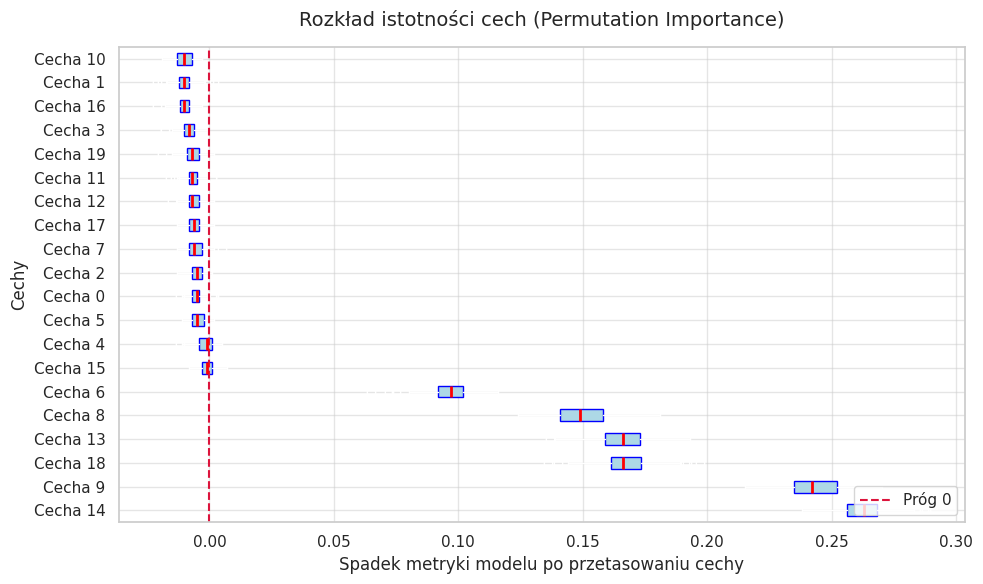

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

feature_names = (
    X_test.columns
    if hasattr(X_test, "columns")
    else [f"Cecha {i}" for i in range(X_test.shape[1])]
)


sorted_importances_idx = result.importances_mean.argsort()[::-1]
sorted_feature_names = [feature_names[i] for i in sorted_importances_idx]
sorted_importances = result.importances[sorted_importances_idx]

plt.figure(figsize=(10, 6))

plt.boxplot(
    sorted_importances.T,
    vert=False,
    labels=sorted_feature_names,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red", linewidth=2),
)

plt.axvline(x=0, color="crimson", linestyle="--", linewidth=1.5, label="Próg 0")

plt.title("Rozkład istotności cech (Permutation Importance)", fontsize=14, pad=15)
plt.xlabel("Spadek metryki modelu po przetasowaniu cechy", fontsize=12)
plt.ylabel("Cechy", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

# LIME

# Shapley I

# Shapley II